## Introduction


In [1]:
from laion_fmri import load_subject
import pandas as pd 
import numpy as np
import inspect
from scipy.spatial import cKDTree
import cortex
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from nibabel.freesurfer.io import read_geometry
from PIL import Image
import io
import h5py
from pathlib import Path
import matplotlib.pyplot as plt

## Loading subject
* Loading Subject 1 
* Loading Betas from session 1 with streaming
* Loading the trials

In [2]:
sub = load_subject("sub-01")
betas = sub.get_betas(session="ses-01", streaming=True)          # (n_trials, n_voxels)
trials = sub.get_trial_info(session="ses-01")    # pandas DataFrame

### Cehck the shapes of betas

In [3]:
print(betas.shape)
print(betas[0].shape)
print(type(betas))

(1044, 272080)
(272080,)
<class 'numpy.ndarray'>


### Plot the trials dataframe with pandas 

In [4]:
df = pd.DataFrame(trials)
print(df.head())

  session  run  beta_index                                          label
0  ses-01    1           0       unique_LAION_new_cluster_475_i49_p01.jpg
1  ses-01    1           1  unique_LAION_initial_cluster_5192_i30_p01.jpg
2  ses-01    1           2         shared_12rep_LAION_cluster_2677_i5.jpg
3  ses-01    1           3   unique_LAION_initial_cluster_4651_i2_p01.jpg
4  ses-01    1           4   unique_LAION_initial_cluster_3457_i4_p01.jpg


### Read the stimulies

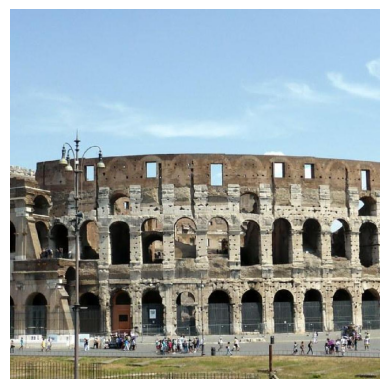

In [5]:
stimuli_dir = Path("/mnt/c/Users/rendo/Documents/BA/laion_fmri_data/stimuli")
h5_path = stimuli_dir / "task-images_stimuli.h5"
with h5py.File(h5_path, "r") as f:
    data = f["images"][22187]
img = Image.open(io.BytesIO(data.tobytes()))
plt.imshow(img)
plt.axis("off")
plt.show()

### Getting the index of the stimuli by using image metadata

In [6]:
csv_path = stimuli_dir / "task-images_metadata.csv"
df = pd.read_csv(csv_path)
idx = df.index[df["image_name"] == "unique_LAION_new_cluster_475_i49_p01.jpg"][0]
print(idx)

22187


### Get the freesurfer files directory

In [7]:
sub.get_freesurfer_dir()

PosixPath('/mnt/c/Users/rendo/Documents/BA/laion_fmri_data/derivatives/freesurfer/sub-01')

### Get the Voxels' Coordinates in 3D space

In [8]:
coords = sub.get_voxel_coordinates(mask_source="anatomical")
coords.shape

(272080, 3)

### Read Fiducial data

In [9]:
surf_dir = Path(
    "/mnt/c/Users/rendo/Documents/BA/laion_fmri_data/derivatives/freesurfer/sub-01/surf"
)
lh_vertices, lh_faces = read_geometry(f"{surf_dir}/lh.fiducial")
rh_vertices, rh_faces = read_geometry(f"{surf_dir}/rh.fiducial")

print("LH vertices:", lh_vertices.shape)
print("LH faces:", lh_faces.shape)

print("RH vertices:", rh_vertices.shape)
print("RH faces:", rh_faces.shape)

LH vertices: (148371, 3)
LH faces: (296738, 3)
RH vertices: (146299, 3)
RH faces: (292594, 3)


### Assign each voxel to left-or right hemisphere

In [10]:
lh_voxels = coords[:, 0] < 0
rh_voxels = coords[:, 0] > 0

print("LAION voxels with X < 0:", lh_voxels.sum())
print("LAION voxels with X > 0:", rh_voxels.sum())
print("LAION voxels with X = 0:", (coords[:, 0] == 0).sum())

LAION voxels with X < 0: 144792
LAION voxels with X > 0: 127288
LAION voxels with X = 0: 0


### PyCortex Default Database

In [11]:
print(cortex.database.default_filestore)

/home/rendo/projects/LAION_fMRI/pycortex-env/share/pycortex/db


In [12]:
print("pycortex version:", cortex.__version__)
print(inspect.signature(cortex.freesurfer.import_subj))

pycortex version: 1.3.2
(freesurfer_subject, pycortex_subject=None, freesurfer_subject_dir=None, whitematter_surf='smoothwm')


### Read 2D Pathfiles using pycortex

In [13]:
import cortex.freesurfer as fs

lh_patch = fs.parse_patch(
    str(surf_dir / "lh.cortex.patch.flat")
)
rh_patch = fs.parse_patch(
    str(surf_dir / "rh.cortex.patch.flat")
)

print("LH:", type(lh_patch), lh_patch.shape)
print("RH:", type(rh_patch), rh_patch.shape)
print("LH first rows:")
print(lh_patch[:5])

LH: <class 'numpy.ndarray'> (137276,)
RH: <class 'numpy.ndarray'> (136171,)
LH first rows:
[(1, 56.69557 , 135.5874 , 0.) (2, 56.476097, 134.37793, 0.)
 (3, 57.977997, 135.88434, 0.) (4, 57.136665, 134.11758, 0.)
 (5, 58.468445, 136.49817, 0.)]


In [14]:
lh_patch_idx = np.abs(lh_patch["vert"]) - 1
rh_patch_idx = np.abs(rh_patch["vert"]) - 1

In [15]:
# Single trial only
trial = np.asarray(betas[10])

# Split by hemisphere
lh_mask = coords[:, 0] < 0
rh_mask = coords[:, 0] > 0

# Build nearest-vertex lookup
lh_tree = cKDTree(lh_vertices)
rh_tree = cKDTree(rh_vertices)

_, lh_nearest = lh_tree.query(coords[lh_mask])
_, rh_nearest = rh_tree.query(coords[rh_mask])

# Accumulate beta values at surface vertices
lh_surface = np.full(len(lh_vertices), np.nan)
rh_surface = np.full(len(rh_vertices), np.nan)

# LH
lh_sum = np.zeros(len(lh_vertices))
lh_count = np.zeros(len(lh_vertices))

np.add.at(lh_sum, lh_nearest, trial[lh_mask])
np.add.at(lh_count, lh_nearest, 1)

valid = lh_count > 0
lh_surface[valid] = lh_sum[valid] / lh_count[valid]

# RH
rh_sum = np.zeros(len(rh_vertices))
rh_count = np.zeros(len(rh_vertices))

np.add.at(rh_sum, rh_nearest, trial[rh_mask])
np.add.at(rh_count, rh_nearest, 1)

valid = rh_count > 0
rh_surface[valid] = rh_sum[valid] / rh_count[valid]

print("LH surface values:", np.sum(~np.isnan(lh_surface)))
print("RH surface values:", np.sum(~np.isnan(rh_surface)))

LH surface values: 79012
RH surface values: 75103


In [16]:
# Patch vertex indices
lh_patch_idx = np.abs(lh_patch["vert"]) - 1
rh_patch_idx = np.abs(rh_patch["vert"]) - 1

# Flat coordinates
lh_flat_xy = np.column_stack([
    lh_patch["x"],
    lh_patch["y"]
])

rh_flat_xy = np.column_stack([
    rh_patch["x"],
    rh_patch["y"]
])

# Surface values corresponding to each patch vertex
lh_flat_values = lh_surface[lh_patch_idx]
rh_flat_values = rh_surface[rh_patch_idx]

print(lh_flat_xy.shape, lh_flat_values.shape)
print(rh_flat_xy.shape, rh_flat_values.shape)

(137276, 2) (137276,)
(136171, 2) (136171,)


In [17]:
def patch_faces(surface_faces, patch_indices):
    """
    Keep faces whose three vertices are present in the flat patch,
    and convert their global vertex indices to patch-local indices.
    """
    global_to_local = np.full(
        surface_faces.max() + 1,
        -1,
        dtype=np.int64
    )

    global_to_local[patch_indices] = np.arange(len(patch_indices))

    keep = np.all(global_to_local[surface_faces] >= 0, axis=1)

    faces = surface_faces[keep]

    return global_to_local[faces]


lh_flat_faces = patch_faces(lh_faces, lh_patch_idx)
rh_flat_faces = patch_faces(rh_faces, rh_patch_idx)

print("LH flat faces:", lh_flat_faces.shape)
print("RH flat faces:", rh_flat_faces.shape)

LH flat faces: (273600, 3)
RH flat faces: (271290, 3)


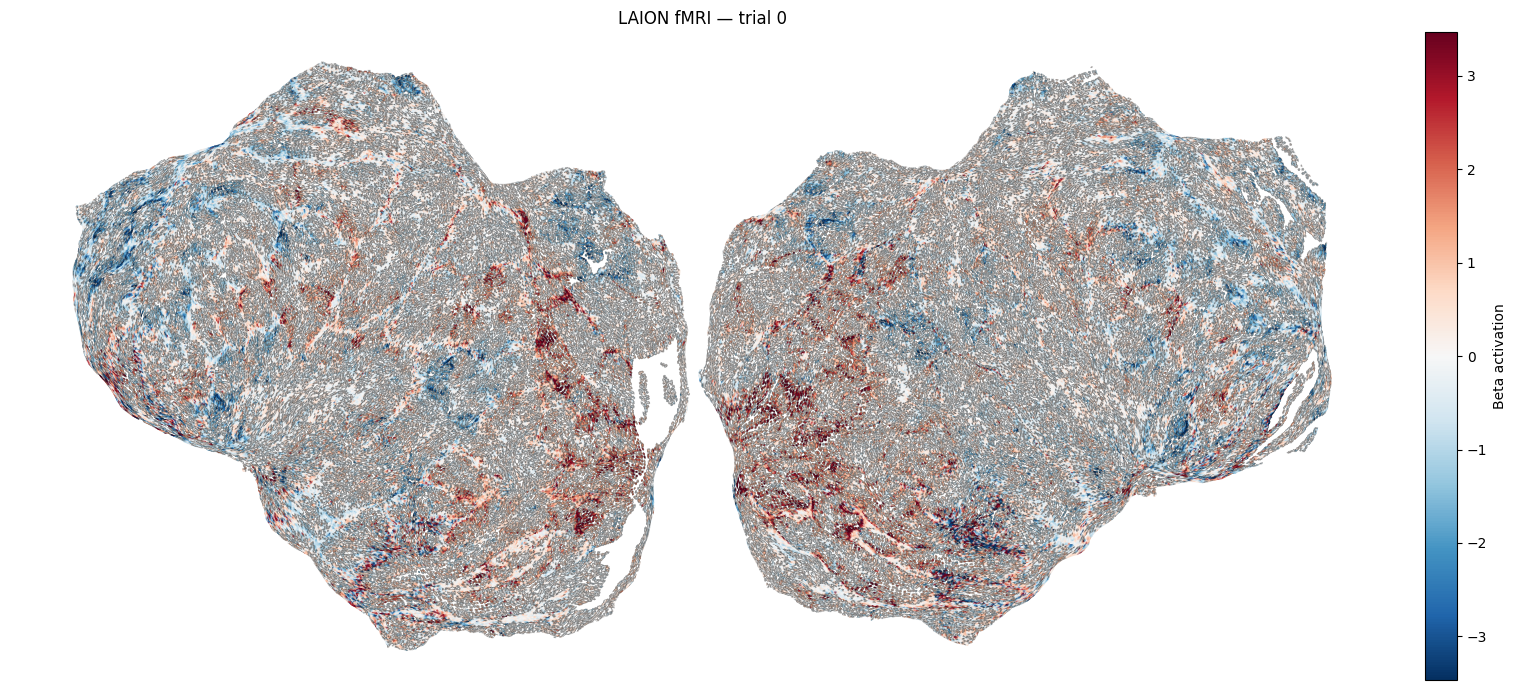

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


# =========================================================
# 1. Patch vertex indices
# =========================================================

lh_patch_idx = np.abs(lh_patch["vert"]) - 1
rh_patch_idx = np.abs(rh_patch["vert"]) - 1


# =========================================================
# 2. Convert FreeSurfer patch coordinates to pycortex
#    flatmap coordinates
#
#    This follows cortex.freesurfer.import_flat():
#
#        flat = pts[:, [1, 0, 2]]
#        flat[:, 1] = -flat[:, 1]
# =========================================================

lh_flat_xy = np.column_stack([
    lh_patch["y"],
    -lh_patch["x"]
])

rh_flat_xy = np.column_stack([
    rh_patch["y"],
    -rh_patch["x"]
])


# =========================================================
# 3. Get beta values for the flatmap vertices
# =========================================================

lh_flat_values = lh_surface[lh_patch_idx]
rh_flat_values = rh_surface[rh_patch_idx]


# =========================================================
# 4. Reconstruct the flatmap triangles
# =========================================================

def patch_faces(surface_faces, patch_indices):

    global_to_local = np.full(
        surface_faces.max() + 1,
        -1,
        dtype=np.int64
    )

    global_to_local[patch_indices] = np.arange(
        len(patch_indices)
    )

    keep = np.all(
        global_to_local[surface_faces] >= 0,
        axis=1
    )

    return global_to_local[surface_faces[keep]]


lh_flat_faces = patch_faces(
    lh_faces,
    lh_patch_idx
)

rh_flat_faces = patch_faces(
    rh_faces,
    rh_patch_idx
)


# =========================================================
# 5. Nudge the hemispheres apart
#
#    This follows pycortex's "nudge=True" convention:
#
#    LH → ends at x = 0
#    RH → starts at x = 0
# =========================================================

lh_plot = lh_flat_xy.copy()
rh_plot = rh_flat_xy.copy()

lh_plot[:, 0] -= lh_plot[:, 0].max()
rh_plot[:, 0] -= rh_plot[:, 0].min()


# Small gap between hemispheres
gap = 5

rh_plot[:, 0] += gap


# =========================================================
# 6. Create triangulations
# =========================================================

lh_tri = mtri.Triangulation(
    lh_plot[:, 0],
    lh_plot[:, 1],
    lh_flat_faces
)

rh_tri = mtri.Triangulation(
    rh_plot[:, 0],
    rh_plot[:, 1],
    rh_flat_faces
)


# =========================================================
# 7. One common color scale
# =========================================================

all_values = np.concatenate([
    lh_flat_values[np.isfinite(lh_flat_values)],
    rh_flat_values[np.isfinite(rh_flat_values)]
])

vmax = np.percentile(
    np.abs(all_values),
    98
)

vmin = -vmax


# =========================================================
# 8. Plot
# =========================================================

fig, ax = plt.subplots(
    figsize=(16, 7)
)


# Left hemisphere
im = ax.tripcolor(
    lh_tri,
    lh_flat_values,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)


# Right hemisphere
ax.tripcolor(
    rh_tri,
    rh_flat_values,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)


# =========================================================
# 9. Formatting
# =========================================================

ax.set_aspect("equal")
ax.axis("off")

ax.set_title(
    "LAION fMRI — trial 0"
)

fig.colorbar(
    im,
    ax=ax,
    fraction=0.025,
    pad=0.02,
    label="Beta activation"
)

plt.tight_layout()
plt.show()